In [2]:
import numpy as np
import matplotlib.gridspec as gridspec
%matplotlib notebook
import pylab
import os.path as op
import mne
import time
from mne.datasets import sample
from mne.preprocessing import ICA
from mne.preprocessing import create_ecg_epochs, create_eog_epochs 
from solvenan2 import *
from run_coupled import *
from scipy import signal
from spectrogramacerto import *
from scipy.stats.stats import pearsonr   
from ValidationICA import * 
from sklearn import metrics
import seaborn

In [3]:
data_path = op.join(mne.datasets.sample.data_path(), 'MEG', 'sample')
raw = mne.io.read_raw_fif(op.join(data_path, 'sample_audvis_raw.fif'), preload=True)
events = mne.read_events(op.join(data_path, 'sample_audvis_raw-eve.fif'))
picks = mne.pick_types(raw.info, meg=False, eeg=True, eog=True)
epochs = mne.Epochs(raw, events, [1, 2], picks=picks)

Opening raw data file /Users/renatobottermaiolopesrodrigues/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
Current compensation grade : 0
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Adding average EEG reference projection.
1 projection items deactivated
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
145 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


<IPython.core.display.Javascript object>


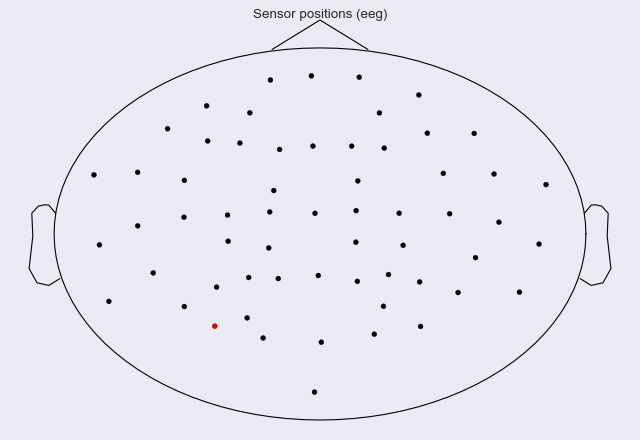

In [4]:
raw.plot_sensors(ch_type='eeg')
plt.show()

In [5]:
pylab.savefig('1.png')

In [6]:
#Hight-Pass Filter
raw.filter(l_freq=1, h_freq=None)

High-pass filtering at 1 Hz


<Raw  |  sample_audvis_raw.fif, n_channels x n_times : 376 x 166800 (277.7 sec)>

Fitting ICA to data using 59 channels. 
Please be patient, this may take some time
Inferring max_pca_components from picks.
Selection by explained variance: 13 components
... filtering ICA sources
... filtering target
EOG channel index for this subject is: [375]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Now detecting blinks and generating corresponding events
Number of EOG events detected : 46
46 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
Loading data for 46 events and 601 original time points ...
0 bad epochs dropped


<IPython.core.display.Javascript object>


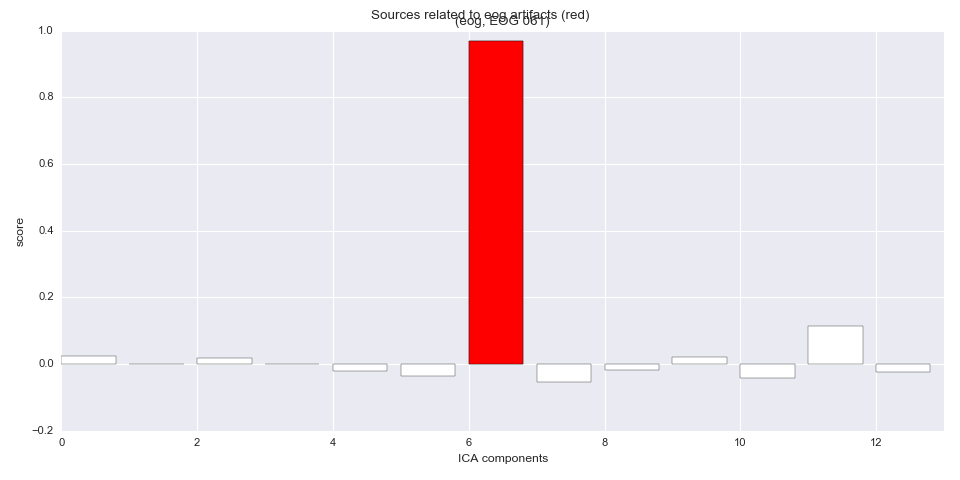

<IPython.core.display.Javascript object>


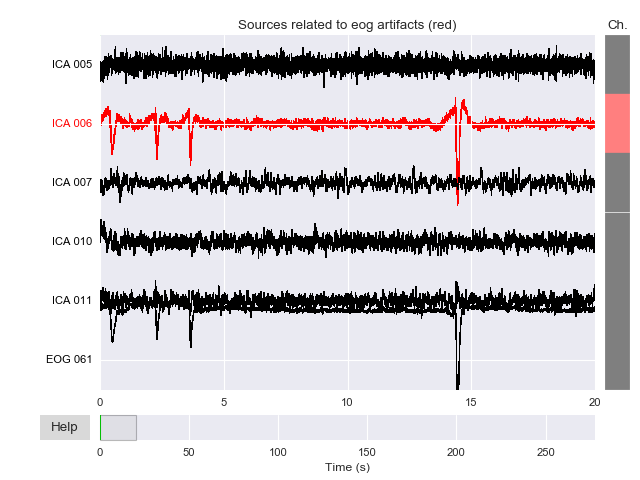

<IPython.core.display.Javascript object>


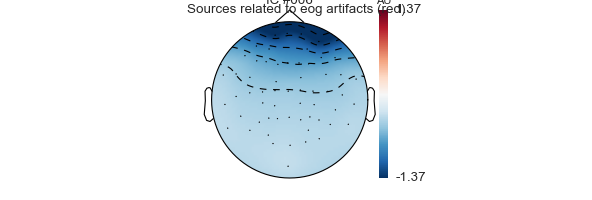

Transforming to ICA space (13 components)
Zeroing out 1 ICA components


<IPython.core.display.Javascript object>


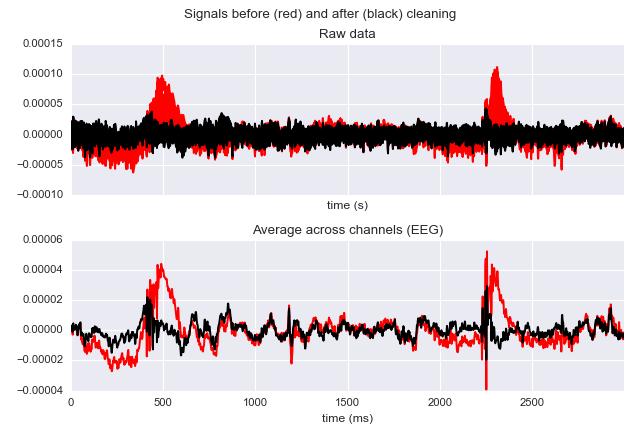

<IPython.core.display.Javascript object>


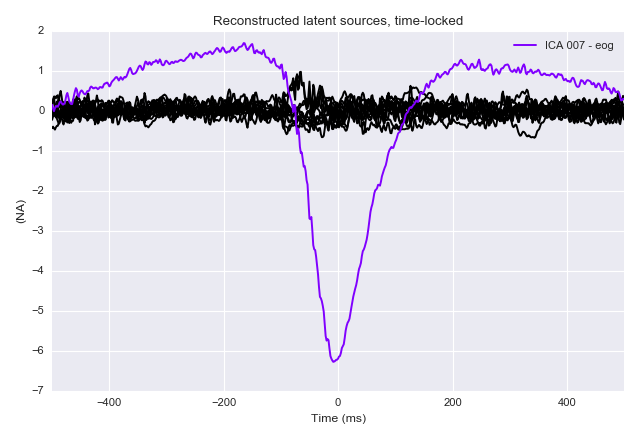

Transforming to ICA space (13 components)
Zeroing out 1 ICA components


<IPython.core.display.Javascript object>


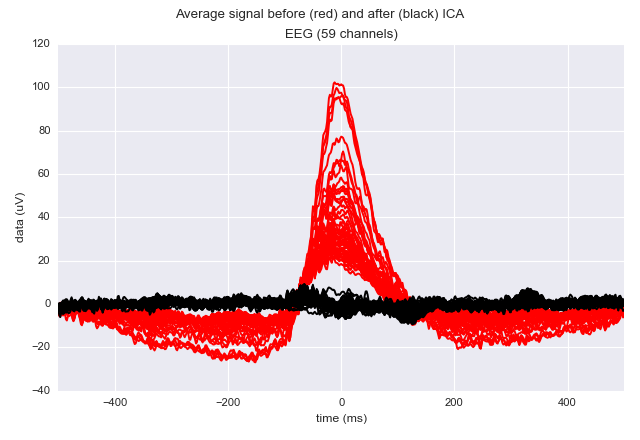

Transforming to ICA space (13 components)
Zeroing out 1 ICA components
Computed in  11.678868 seconds


In [7]:
#Get results from ICA method
t0 = time.clock()
eeg_only_after_ica=ica_method(raw.copy(), picks, 'y', 'y')
print('Computed in ', time.clock()-t0, 'seconds')
# images saved in 2 to 7

In [8]:
eeg_only = raw.copy().pick_types(meg=False, eeg=True)
eeg_only1 = raw.copy().pick_types(meg=False, eeg=True)
eog_only = raw.copy().pick_types(meg=False, eeg=False, eog=True)

<IPython.core.display.Javascript object>


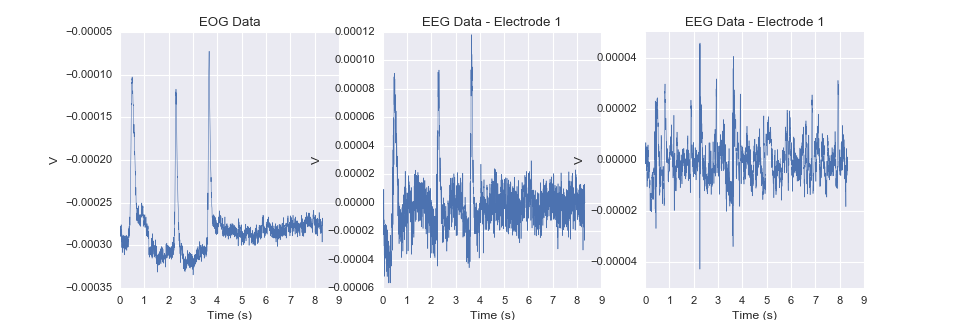

In [9]:

npoint=5000
fig=plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.plot( eog_only._times[0:npoint], -eog_only._data[0,0:npoint], linewidth=0.5 )
plt.title('EOG Data')
plt.xlabel('Time (s)')
plt.ylabel('V')

plt.subplot(1,3,2)
plt.plot( eeg_only._times[0:npoint], eeg_only._data[0,0:npoint], linewidth=0.5 )
plt.title('EEG Data - Electrode 1')
plt.xlabel('Time (s)')
plt.ylabel('V')

plt.subplot(1,3,3)
plt.plot( eeg_only._times[0:npoint], eeg_only._data[58,0:npoint], linewidth=0.5 )
plt.title('EEG Data - Electrode 1')
plt.xlabel('Time (s)')
plt.ylabel('V')

In [10]:
pylab.savefig('8.png')

In [11]:
#Parameters to calculate TFCT
sfreq = eog_only.info['sfreq']
Fs=sfreq
Tau = 0.7
hopsize=1/8
win='h'
Nw=np.round(Tau * Fs)
R = np.round(hopsize * Nw) 
N = eeg_only._data.shape[1]
Nt = np.array([np.fix((N-Nw)/R)])

#Channels to analyse 
ch=np.arange(0,59,1)

In [12]:
V2 = np.zeros([int(Nw), int (Nt[0]), len(ch)]) 
v2 = np.zeros([int(Nw), int (Nt[0]), len(ch)])                       
Ph2 = np.zeros([int(Nw), int (Nt[0]), len(ch)])            
n2=np.zeros([len(ch),1])

In [13]:
for m in range(0, len(ch)):   
    V2[:,:,m], Ph2[:,:,m], tr2, f2 = spectrogramme(eeg_only._data[ch[m],:],Fs,Tau,hopsize, win)
    v2[:,:,m] = V2[:,:,m]/np.max(np.absolute(V2[:,:,m]))
    n2[m]=np.max(np.abs(V2[:,:,m]))

In [14]:
#Solve segments if Nan

solvenan2(eog_only._data)

V1,Ph1,tr1,f1 = spectrogramme(eog_only._data[0,:],Fs,Tau,hopsize, win)
v1 = V1/np.max(np.absolute(V1))
n1=np.max(np.abs(V1))

<IPython.core.display.Javascript object>


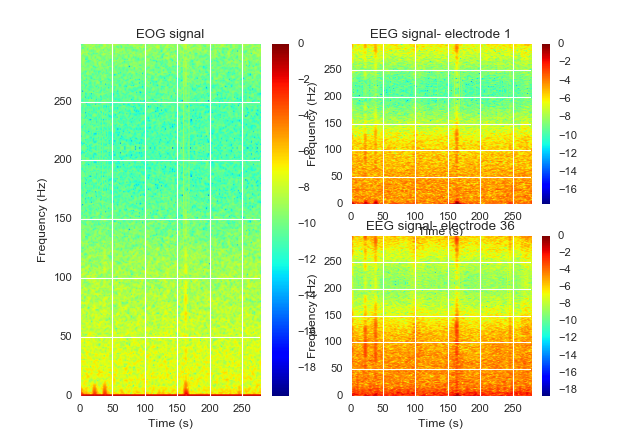

In [15]:
fig = plt.figure()
gs = gridspec.GridSpec(2, 2)
ax1 = fig.add_subplot(gs[0,1:])
plot_spectrogram(v2[:,:,0], np.max(f2), np.max(eeg_only._times))
plt.title('EEG signal- electrode 1')

electrode_number=36
ax2 = fig.add_subplot(gs[1,1:])
plot_spectrogram(v2[:,:,electrode_number], np.max(f2), np.max(eeg_only._times))
plt.title('EEG signal- electrode 36')

ax3 = fig.add_subplot(gs[0:, 0])
plot_spectrogram(v1, np.max(f1), np.max(eog_only._times))
plt.title('EOG signal')

In [16]:
pylab.savefig('9.png')

In [17]:
#NTF
if v1.ndim==2 and v2.ndim==3:
    w1, h1, w2, h2, q2=ntf_coupled2(v1,v2, ninit=2, niter=10)
elif v1.ndim==2 and v2.ndim==2:
    w1, h1, w2, h2=ntf_coupled2(v1,v2, ninit=2, niter=10)
else:
    w1, h1,q1, w2, h2, q2=ntf_coupled2(v1,v2, ninit=2, niter=10)

100%|██████████| 9/9 [07:00<00:00, 46.10s/it]


In [18]:
K1=24
K2=100

In [19]:

if v1.ndim==2:
    Vhat1=rebuild (w1,h1)
else:
    Vhat1=rebuild (w1,h1, Q=q1)
    
if v2.ndim==2:
    Vhat2=rebuild (w2,h2)
    Vclean_T=rebuild(w2[:,0:K1],h2[:,0:K1])
    Vres_T=rebuild(w2[:,K1:w2.shape[1]],h2[:,K1:h2.shape[1]])
    
else:
    Vhat2=rebuild (w2,h2,Q=q2)
    Vclean_T=rebuild(w2[:,0:K1],q2[:,0:K1],h2[:,0:K1])
    Vres_T=rebuild(w2[:,K1:w2.shape[1]],q2[:,K1:q2.shape[1]],h2[:,K1:h2.shape[1]])

In [20]:
#Initialise 
I = np.round(hopsize * int(Nw))                      
M = 2 * (Vclean_T.shape[0]-1)                       
L = np.ceil( (Vclean_T.shape[2]-1)*int(I) + int(M) )

xclean=np.zeros([int(L),59])
xexg=np.zeros([int(L),59])

In [21]:
for m in tqdm(range(0,v2.shape[2])):
#for m in range(0,v2.shape[2]):
        
   V_clean=n2[m]*v2[:,:,m]*(np.power(Vclean_T[:,m,:],2)/(np.power(Vclean_T[:,m,:],2) + np.power(Vres_T[:,m,:],2)))
   V_artefacts=n1*v2[:,:,m]*(np.power(Vres_T[:,m,:],2)/(np.power(Vclean_T[:,m,:],2) + np.power(Vres_T[:,m,:],2)))
   
   xclean[:,m]=spectrogramme_inv(V_clean,Ph2[:,:,m],Fs,Tau,hopsize,win)[:,0]
   xexg[:,m]=spectrogramme_inv(V_artefacts,Ph1,Fs,Tau,hopsize,win)[:,0]

  0%|          | 0/59 [00:00<?, ?it/s]/Users/renatobottermaiolopesrodrigues/Desktop/ProjectSigma/Script_python/spectrogramacerto.py:97: ComplexWarning: Casting complex values to real discards the imaginary part
  y_aux[:,0] = Xtilde_inv*window
100%|██████████| 59/59 [00:44<00:00,  1.50it/s]


<IPython.core.display.Javascript object>


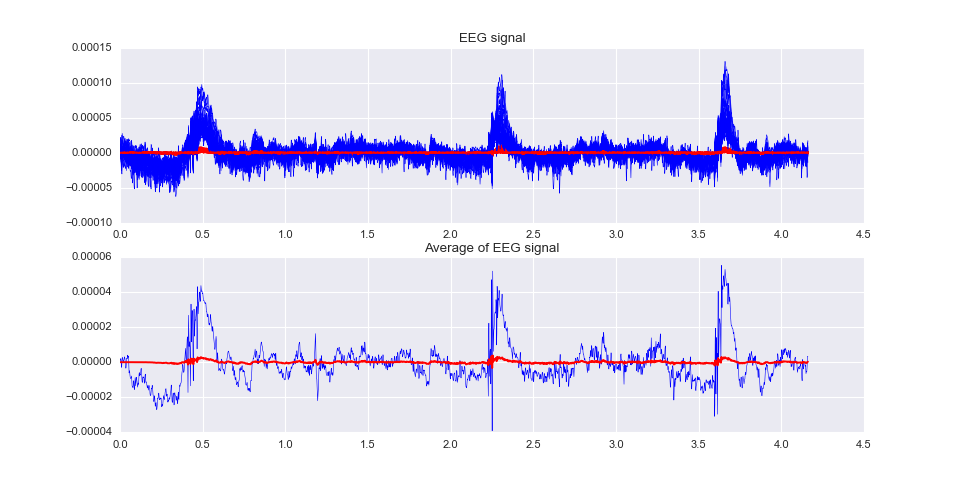

In [22]:
#Plot results
tmax=2500
tmax_a=tmax
f1=plt.figure(figsize=(12,6), dpi=80)
plt.subplot(2,1,1)
for k in range(0,59):
    plt.plot(eeg_only1._times[0:tmax],np.transpose (eeg_only1._data)[0:tmax,k],  color='b', linewidth=0.5)
    plt.plot(eeg_only1._times[0:tmax],xclean[0:tmax,k], color='r')
    plt.title('EEG signal')
plt.subplot(2,1,2)
plt.plot(eeg_only1._times[0:tmax], np.mean(eeg_only1._data[:,0:tmax], axis=0),  color='b', linewidth=0.5)
plt.plot(eeg_only1._times[0:tmax],np.mean(xclean[0:tmax,:], axis=1),  color='r')
plt.title('Average of EEG signal')

In [23]:
pylab.savefig('10.png')

In [24]:
#Get the evoked potencial 

#Raw data
epochs_before = mne.Epochs(eeg_only1, events)
evoked_before = epochs_before.average()

320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


In [25]:
#Get the evoked potencial 

#ICA data
epochs_after_ICA = mne.Epochs(eeg_only_after_ica, events)
evoked_after_ICA = epochs_after_ICA.average()

#NTF data
for m in range(0, len(ch)):
    eeg_only._data[ch[m],:]=xclean[0:eeg_only._data.shape[1],ch[m]]

epochs_after_NMF = mne.Epochs(eeg_only, events)
evoked_after_NMF = epochs_after_NMF.average()


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated
320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


<IPython.core.display.Javascript object>


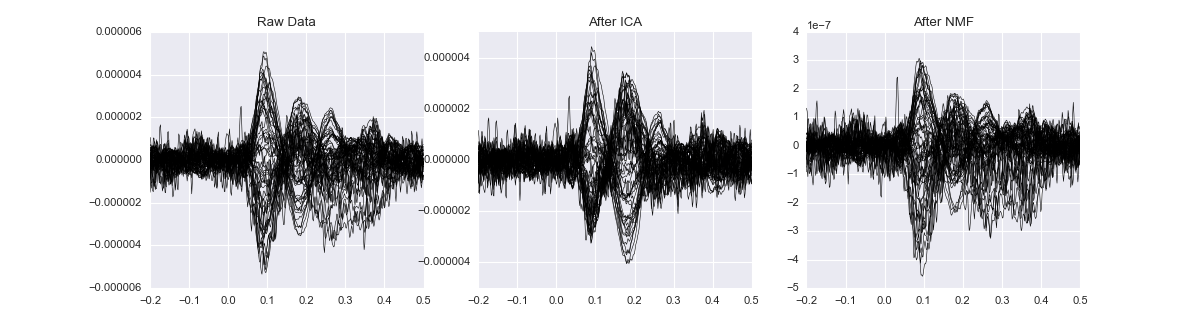

In [26]:
#Plot results from evoked potencial 

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
for k in range(0,59):
    plt.plot(evoked_before.times,evoked_before.data[k,:], color='k', linewidth=0.5)
plt.title('Raw Data')

plt.subplot(1,3,2)
for k in range(0,59):
    plt.plot(evoked_after_ICA.times,evoked_after_ICA.data[k,:], color='k', linewidth=0.5)
    plt.title('After ICA')


plt.subplot(1,3,3)
for k in range(0,59):
    plt.plot(evoked_after_NMF.times,evoked_after_NMF.data[k,:], color='k', linewidth=0.5)
    plt.title('After NMF')

In [27]:
pylab.savefig('11.png')

<IPython.core.display.Javascript object>


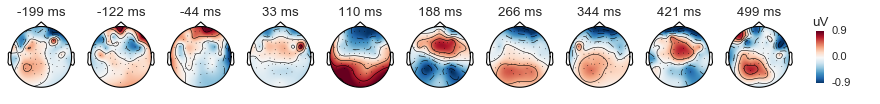

In [28]:
#Plot topographic map of evoked potencial (RAW DATA)
evoked_before.plot_topomap( ch_type='eeg')
plt.show()

In [29]:
pylab.savefig('12.png')

<IPython.core.display.Javascript object>


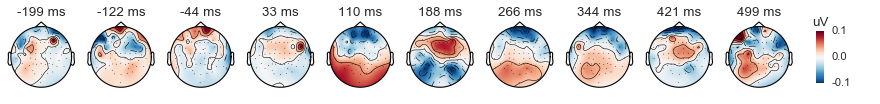

In [30]:
#Plot topographic map of evoked potencial (AFTER NTF)
evoked_after_NMF.plot_topomap( ch_type='eeg')
plt.show()

In [31]:
pylab.savefig('13.png')

<IPython.core.display.Javascript object>


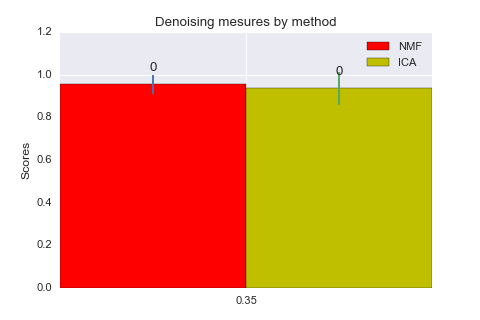

In [63]:
#Comparation with the results obtnaied ICA

N=eeg_only1._data.shape[0]

cm_ICA=np.zeros([1,N])
cm_NMF=np.zeros([1,N])
mi_ICA=np.zeros([1,N])
mi_NMF=np.zeros([1,N])

for k in range(0,N):
    temp=pearsonr(evoked_before.data[k,:],evoked_after_ICA.data[k,:])    
    cm_ICA[0,k]=temp[0]
    temp=pearsonr(evoked_before.data[k,:],evoked_after_NMF.data[k,:])    
    cm_NMF[0,k]=temp[0]
    temp=metrics.mutual_info_score(evoked_before.data[k,:],evoked_after_ICA.data[k,:])    
    mi_ICA[0,k]=temp
    temp=metrics.mutual_info_score(evoked_before.data[k,:],evoked_after_NMF.data[k,:])    
    mi_NMF[0,k]=temp
    #metrics.normalized_mutual_info_score([1, 1, 0, 0], [1, 0, 1, 1])
    
#http://matplotlib.org/examples/api/barchart_demo.html

N = 1
NMFMeans = (np.mean(cm_NMF))#, np.mean(mi_NMF))
NMFStd = (np.std(cm_NMF))#, np.std(mi_NMF))

ind = np.arange(N)  # the x locations for the groups
width = 0.35       # the width of the bars

plt.figure(figsize=(6,4))
#fig, ax = plt.subplots()
rects1 = plt.bar(ind, NMFMeans, width, color='r', yerr=NMFStd)

ICAMeans = (np.mean(cm_ICA))#, np.mean(mi_ICA))
ICAStd = (np.std(cm_ICA))#, np.std(mi_ICA))
rects2 = plt.bar(ind + width, ICAMeans, width, color='y', yerr=ICAStd)

# add some text for labels, title and axes ticks
plt.ylabel('Scores')
plt.title('Denoising mesures by method')
plt.xticks(ind + width)
#plt.xlabel(('CP', 'MI'))
plt.legend((rects1[0], rects2[0]), ('NMF', 'ICA'))

def autolabel(rects):
    # attach some text labels
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x() + rect.get_width()/2., 1.05*height,
                '%d' % int(height),
                ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
plt.show()

In [33]:
pylab.savefig('14.png')

In [39]:
#Analyse with only one electrode NMF
eeg_only_NMF = raw.copy().pick_types(meg=False, eeg=True)

#sensors=np.array([3, 19, 24, 34, 57])
#sensors=np.array([50, 1, 15, 6])

#N=len(sensors)
N=eeg_only1._data.shape[0]
norm2_NMF_1=np.zeros([1,N])
cm_NMF_1=np.zeros([1,N])
mi_NMF_1=np.zeros([1,N])
evoked_after_NMF_1=np.zeros(evoked_before.data.shape)
#for m in tqdm(range(0, len(sensors))):

notnan_channels=np.zeros(N)
count=0

aux_eeg=np.zeros([eeg_only_NMF._data.shape[1], N ])

for m in range(0, N):   
    V2_1, Ph2_1, tr2_1, f2_1 = spectrogramme(eeg_only1._data[m,:],Fs,Tau,hopsize, win)
    v2_1 = V2_1/np.max(np.absolute(V2_1))
    n2_1=np.max(np.abs(V2_1))
    
    w1_1, h1_1, w2_1, h2_1 = ntf_coupled2(v1,v2_1, ninit=2, niter=10)
    
    Vhat1_1=rebuild (w1_1,h1_1)
    Vhat2_1=rebuild (w2_1,h2_1)
    
    Vclean_T_1=rebuild(w2_1[:,0:K1],h2_1[:,0:K1])
    Vres_T_1=rebuild(w2_1[:,K1:w2_1.shape[1]],h2_1[:,K1:h2_1.shape[1]])
    
    V_clean_1=n2_1*v2_1*(np.power(Vclean_T_1,2)/(np.power(Vclean_T_1,2) + np.power(Vres_T_1,2)))
    V_artefacts_1=n1*v2_1*(np.power(Vres_T_1,2)/(np.power(Vclean_T_1,2) + np.power(Vres_T_1,2)))
    
    xclean_1=spectrogramme_inv(V_clean_1,Ph2_1,Fs,Tau,hopsize,win)[:,0]
    xexg_1=spectrogramme_inv(V_artefacts_1,Ph1,Fs,Tau,hopsize,win)[:,0]
    
    if not np.any(np.isnan(xclean_1)):
        
        aux_eeg[:,count]=xclean_1[0:eeg_only_NMF._data.shape[1]]
        notnan_channels[count]=m
        count+=1

for i in range(0, int (count)):
    eeg_only_NMF._data[notnan_channels[i], :]=aux_eeg[:, i]

epochs_after_NMF_1 = mne.Epochs(eeg_only_NMF, events)    
evoked_after_NMF_1 = epochs_after_NMF_1.average()

for i in range(0, count):
    temp=pearsonr(evoked_before.data[notnan_channels[i],:],evoked_after_NMF_1.data[notnan_channels[i],:])   
    cm_NMF_1[0,i]=temp[0]


 89%|████████▉ | 8/9 [00:03<00:00,  2.09it/s]
/Users/renatobottermaiolopesrodrigues/Desktop/ProjectSigma/Script_python/spectrogramacerto.py:97: ComplexWarning: Casting complex values to real discards the imaginary part
  y_aux[:,0] = Xtilde_inv*window
 89%|████████▉ | 8/9 [00:03<00:00,  2.21it/s]
/Users/renatobottermaiolopesrodrigues/anaconda3/lib/python3.5/site-packages/ipykernel/__main__.py:46: DeprecationWarning: using a non-integer number instead of an integer will result in an error in the future


320 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
4 projection items activated


/Users/renatobottermaiolopesrodrigues/anaconda3/lib/python3.5/site-packages/ipykernel/__main__.py:52: DeprecationWarning: using a non-integer number instead of an integer will result in an error in the future


<IPython.core.display.Javascript object>


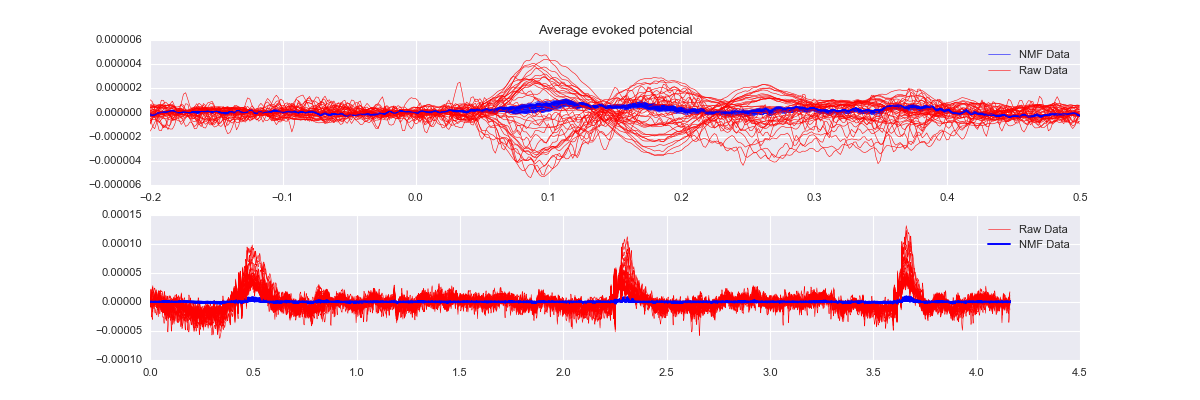

In [47]:
##http://matplotlib.org/examples/api/barchart_demo.html


fig = plt.figure(figsize=(15,5))
gs = gridspec.GridSpec(2, 2)
#ax1 = fig.add_subplot(gs[0:, 0])

#PCMeans_1 = cm_NMF_1
#ind = np.arange(N)  # the x locations for the groups
#width = 0.3       # the width of the bars

#for i in range(0, int (count)):
#    plt.bar(ind[i], PCMeans_1[0][i], width)

## add some text for labels, title and axes ticks
#plt.ylabel('Pearson Correlation')
#plt.title('Person Correlation of the average evoked data')
#plt.xticks(ind + width)

fig.add_subplot(gs[0,0:])

for m in range(0, int(count)):   
    if m==0:
        plt.plot(evoked_after_NMF_1.times,evoked_after_NMF_1.data[int (notnan_channels[m]),:], color='b', linewidth=0.5, label ='NMF Data')
        plt.plot(evoked_before.times,evoked_before.data[int (notnan_channels[m]),:], color='r', linewidth=0.5, label='Raw Data')
    else:
        plt.plot(evoked_after_NMF_1.times,evoked_after_NMF_1.data[int (notnan_channels[m]),:], color='b', linewidth=0.5)
        plt.plot(evoked_before.times,evoked_before.data[int (notnan_channels[m]),:], color='r', linewidth=0.5)

plt.legend()
plt.title('Average evoked potencial')

fig.add_subplot(gs[1,0:])

tmax=2500
tmax_a=2500

for k in range(0, int(count)):
    if k==0:
        plt.plot(eeg_only_NMF._times[0:tmax],np.transpose (eeg_only1._data)[0:tmax, int(notnan_channels[k])],  color='r', linewidth=0.5, label='Raw Data')
        plt.plot(eeg_only_NMF._times[0:tmax],eeg_only_NMF._data[int (notnan_channels[k]), 0:tmax], color='b', label='NMF Data')
    else:
        plt.plot(eeg_only_NMF._times[0:tmax],np.transpose (eeg_only1._data)[0:tmax, int(notnan_channels[k])],  color='r', linewidth=0.5)
        plt.plot(eeg_only_NMF._times[0:tmax],eeg_only_NMF._data[int (notnan_channels[k]), 0:tmax], color='b')

plt.legend()
plt.show()

In [64]:
pylab.savefig('15.png')

In [66]:
print('Nombre of non Nan channels: ', count)

Nombre of non Nan channels:  40


In [67]:
notnan_channels

array([  0.,   2.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,  13.,
        14.,  17.,  18.,  22.,  23.,  24.,  25.,  26.,  28.,  31.,  33.,
        34.,  36.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,
        48.,  49.,  50.,  51.,  53.,  54.,  55.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.])